# Assignment 2 — SARSA and Q-Learning for Taxi and Cliff Walking

**Reinforcement Learning · IE University · Jaume Manero · April 2026**
**Author: Juan Vintimilla**

This notebook covers the four activities of HW2:

1. **Activity 1** — SARSA on Taxi-v3
2. **Activity 2** — Q-Learning on Taxi-v3
3. **Activity 3** — SARSA vs Q-Learning on CliffWalking
4. (Bonus videos — optional, skipped)

It also answers the five questions of Section 4 of the spec.

## AI policy disclosure

The two algorithm update loops (SARSA and Q-Learning) were implemented by
hand following Sutton & Barto Ch. 6. AI assistance was used for refactor,
plotting helpers, and this notebook prose. Every `Q[s, a] += α (target − Q[s, a])`
update was verified against the textbook before running.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from dataclasses import dataclass

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('numpy:', np.__version__)
print('gymnasium:', gym.__version__)


numpy: 2.4.4
gymnasium: 1.2.3


## Algorithms — SARSA and Q-Learning

Both algorithms follow the same skeleton (ε-greedy exploration, decaying ε,
single TD step) and differ ONLY in the bootstrap target:

- **SARSA** (on-policy):  $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\,Q(s', a') - Q(s,a)\,]$
  where $a'$ is the action the ε-greedy policy WILL ACTUALLY TAKE next.
- **Q-Learning** (off-policy):  $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\,\max_{a'} Q(s', a') - Q(s,a)\,]$
  uses the maximum over actions in the next state, regardless of the policy.


In [2]:
@dataclass
class TrainingResult:
    Q: np.ndarray
    returns: np.ndarray
    lengths: np.ndarray


def epsilon_greedy(Q, s, eps, n_actions, rng):
    if rng.random() < eps:
        return int(rng.integers(n_actions))
    qs = Q[s]
    candidates = np.flatnonzero(qs == qs.max())
    return int(rng.choice(candidates))


def eps_schedule(ep, total, eps_start, eps_end, decay_frac):
    decay_eps = max(1, int(total * decay_frac))
    frac = min(1.0, ep / decay_eps)
    return eps_start + frac * (eps_end - eps_start)


def sarsa(env, num_episodes=10_000, alpha=0.1, gamma=0.99,
          eps_start=1.0, eps_end=0.05, decay_frac=0.8,
          max_steps=1000, seed=0):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_states, n_actions))
    returns = np.zeros(num_episodes, dtype=np.float32)
    lengths = np.zeros(num_episodes, dtype=np.int32)
    for ep in range(num_episodes):
        eps = eps_schedule(ep, num_episodes, eps_start, eps_end, decay_frac)
        s, _ = env.reset(seed=int(rng.integers(1 << 31)))
        a = epsilon_greedy(Q, s, eps, n_actions, rng)
        ep_ret, steps = 0.0, 0
        while steps < max_steps:
            s_next, r, done, truncated, _ = env.step(a)
            a_next = epsilon_greedy(Q, s_next, eps, n_actions, rng)
            target = r + gamma * Q[s_next, a_next] * (0.0 if done else 1.0)
            Q[s, a] += alpha * (target - Q[s, a])    # <-- SARSA UPDATE
            s, a = s_next, a_next
            ep_ret += r
            steps += 1
            if done or truncated:
                break
        returns[ep] = ep_ret
        lengths[ep] = steps
    return TrainingResult(Q, returns, lengths)


def q_learning(env, num_episodes=10_000, alpha=0.1, gamma=0.99,
               eps_start=1.0, eps_end=0.05, decay_frac=0.8,
               max_steps=1000, seed=0):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_states, n_actions))
    returns = np.zeros(num_episodes, dtype=np.float32)
    lengths = np.zeros(num_episodes, dtype=np.int32)
    for ep in range(num_episodes):
        eps = eps_schedule(ep, num_episodes, eps_start, eps_end, decay_frac)
        s, _ = env.reset(seed=int(rng.integers(1 << 31)))
        ep_ret, steps = 0.0, 0
        while steps < max_steps:
            a = epsilon_greedy(Q, s, eps, n_actions, rng)
            s_next, r, done, truncated, _ = env.step(a)
            target = r + gamma * Q[s_next].max() * (0.0 if done else 1.0)
            Q[s, a] += alpha * (target - Q[s, a])    # <-- Q-LEARNING UPDATE
            s = s_next
            ep_ret += r
            steps += 1
            if done or truncated:
                break
        returns[ep] = ep_ret
        lengths[ep] = steps
    return TrainingResult(Q, returns, lengths)


def evaluate_greedy(env, Q, episodes=500, max_steps=200, seed=123):
    rng = np.random.default_rng(seed)
    returns = np.zeros(episodes)
    lengths = np.zeros(episodes, dtype=np.int32)
    for ep in range(episodes):
        s, _ = env.reset(seed=int(rng.integers(1 << 31)))
        ep_ret, steps, done, truncated = 0.0, 0, False, False
        while not (done or truncated) and steps < max_steps:
            a = int(Q[s].argmax())
            s, r, done, truncated, _ = env.step(a)
            ep_ret += r
            steps += 1
        returns[ep] = ep_ret
        lengths[ep] = steps
    return returns, lengths


def evaluate_random(env, episodes=500, max_steps=200, seed=999):
    rng = np.random.default_rng(seed)
    returns = np.zeros(episodes)
    lengths = np.zeros(episodes, dtype=np.int32)
    for ep in range(episodes):
        s, _ = env.reset(seed=int(rng.integers(1 << 31)))
        ep_ret, steps, done, truncated = 0.0, 0, False, False
        while not (done or truncated) and steps < max_steps:
            a = int(rng.integers(env.action_space.n))
            s, r, done, truncated, _ = env.step(a)
            ep_ret += r
            steps += 1
        returns[ep] = ep_ret
        lengths[ep] = steps
    return returns, lengths


def smooth(y, k):
    k = max(1, min(k, len(y) // 4))
    return np.convolve(y, np.ones(k) / k, mode='valid')


def _resolve_env(base, versions):
    for v in versions:
        env_id = f'{base}-{v}'
        try:
            gym.spec(env_id)
            return env_id
        except Exception:
            continue
    raise RuntimeError(f'No registered version of {base}')


TAXI_ID = _resolve_env('Taxi', ['v3', 'v4'])
CLIFF_ID = _resolve_env('CliffWalking', ['v0', 'v1'])
print(f'Taxi env: {TAXI_ID}')
print(f'Cliff env: {CLIFF_ID}')


Taxi env: Taxi-v3
Cliff env: CliffWalking-v1


## Activity 1 — SARSA on Taxi-v3

**Environment**: 500 states (taxi pos × passenger loc × destination) × 6 actions
(N/S/E/W/pickup/dropoff). Reward = −1 per step, +20 successful dropoff, −10 illegal action.

**Hyperparameters**: α=0.1, γ=0.99, ε decays from 1.0 → 0.05 over the first 80% of episodes,
N=10,000 episodes.


In [3]:
env = gym.make(TAXI_ID)
print(f'|S| = {env.observation_space.n}, |A| = {env.action_space.n}')

# Random baseline (for comparison)
rand_ret, rand_len = evaluate_random(env, episodes=500, seed=999)
print(f'Random baseline: mean reward = {rand_ret.mean():.2f}, mean length = {rand_len.mean():.1f}')

# Train SARSA over 3 seeds for statistical robustness, 20k episodes each (60k total).
SEEDS = [42, 123, 456]
N_EP_TAXI = 20_000
print(f'\nTraining SARSA on Taxi — {len(SEEDS)} seeds × {N_EP_TAXI} episodes = {len(SEEDS)*N_EP_TAXI} total...')
sarsa_taxi_runs = []
for s in SEEDS:
    print(f'  seed {s}...', end='', flush=True)
    sarsa_taxi_runs.append(sarsa(env, num_episodes=N_EP_TAXI, alpha=0.1, gamma=0.99, seed=s))
    print(' done')

# Use first seed (42) as the canonical Q-table for visualisations; aggregate the
# training curves across seeds for the learning-curve plot.
sarsa_taxi = sarsa_taxi_runs[0]

# Evaluate each seed's policy independently and report mean ± std across seeds.
sarsa_evals = np.array([evaluate_greedy(env, r.Q, episodes=500, seed=123)[0].mean() for r in sarsa_taxi_runs])
print(f'\nSARSA learned policy (mean across {len(SEEDS)} seeds):')
print(f'  reward = {sarsa_evals.mean():.2f} ± {sarsa_evals.std():.2f}')
print(f'  per-seed: {[f"{x:.2f}" for x in sarsa_evals]}')
print(f'  improvement over random: {sarsa_evals.mean() - rand_ret.mean():+.1f}')

# Single-seed (42) detailed eval for downstream cells
sarsa_eval_ret, sarsa_eval_len = evaluate_greedy(env, sarsa_taxi.Q, episodes=500, seed=123)


|S| = 500, |A| = 6


Random baseline: mean reward = -769.42, mean length = 196.6

Training SARSA on Taxi — 3 seeds × 20000 episodes = 60000 total...
  seed 42...

 done
  seed 123...

 done
  seed 456...

 done

SARSA learned policy (mean across 3 seeds):
  reward = 7.87 ± 0.00
  per-seed: ['7.87', '7.87', '7.86']
  improvement over random: +777.3


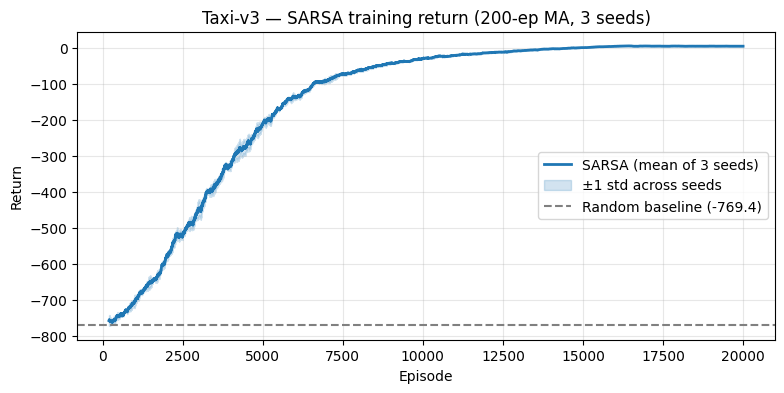

In [4]:
# Visualise SARSA Taxi training curve — mean ± std across 3 seeds
fig, ax = plt.subplots(figsize=(9, 4))
sarsa_returns_stack = np.stack([r.returns for r in sarsa_taxi_runs])  # (3 seeds, N episodes)
window = 200
smoothed = np.stack([smooth(s, window) for s in sarsa_returns_stack])
mean_curve = smoothed.mean(axis=0)
std_curve = smoothed.std(axis=0)
x = np.arange(len(mean_curve)) + window - 1
ax.plot(x, mean_curve, color='C0', linewidth=2, label='SARSA (mean of 3 seeds)')
ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, color='C0', alpha=0.20, label='±1 std across seeds')
ax.axhline(rand_ret.mean(), color='gray', linestyle='--', label=f'Random baseline ({rand_ret.mean():.1f})')
ax.set_title(f'{TAXI_ID} — SARSA training return (200-ep MA, 3 seeds)')
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.legend(); ax.grid(alpha=0.3)
plt.show()


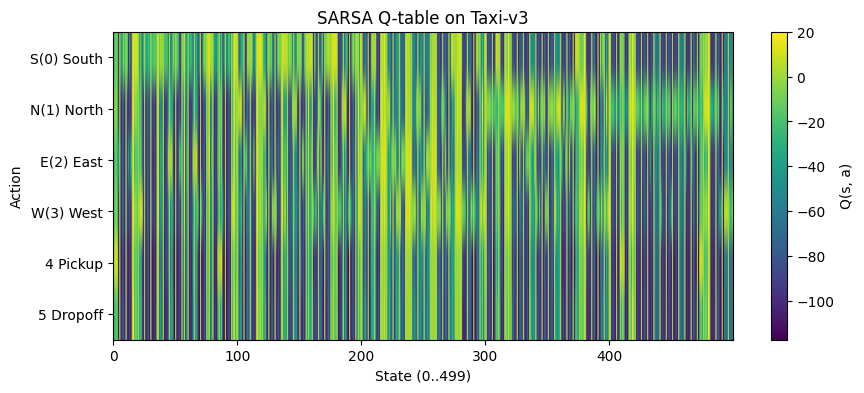

Action distribution in learned policy:
  South   : 214 states (42.8%)
  North   : 139 states (27.8%)
  East    :  55 states (11.0%)
  West    :  76 states (15.2%)
  Pickup  :  12 states (2.4%)
  Dropoff :   4 states (0.8%)


In [5]:
# Q-table heatmap — show learned Q values per state-action
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(sarsa_taxi.Q.T, aspect='auto', cmap='viridis')
ax.set_xlabel(f'State (0..{sarsa_taxi.Q.shape[0]-1})')
ax.set_ylabel('Action')
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['S(0) South', 'N(1) North', 'E(2) East', 'W(3) West', '4 Pickup', '5 Dropoff'])
ax.set_title(f'SARSA Q-table on {TAXI_ID}')
plt.colorbar(im, ax=ax, label='Q(s, a)')
plt.show()

# Policy: best action per state
policy = sarsa_taxi.Q.argmax(axis=1)
action_names = ['South', 'North', 'East', 'West', 'Pickup', 'Dropoff']
print('Action distribution in learned policy:')
for i, name in enumerate(action_names):
    count = int((policy == i).sum())
    print(f'  {name:8s}: {count:3d} states ({count / len(policy) * 100:.1f}%)')


## Activity 2 — Q-Learning on Taxi-v3

Same hyperparameters as Activity 1 so we can compare directly. The only change
in the algorithm is the bootstrap target — we use $\max_{a'} Q(s', a')$ instead
of $Q(s', a')$ where $a'$ is the ε-greedy choice.


In [6]:
env = gym.make(TAXI_ID)
print(f'Training Q-Learning on Taxi — {len(SEEDS)} seeds × {N_EP_TAXI} episodes...')
ql_taxi_runs = []
for s in SEEDS:
    print(f'  seed {s}...', end='', flush=True)
    ql_taxi_runs.append(q_learning(env, num_episodes=N_EP_TAXI, alpha=0.1, gamma=0.99, seed=s))
    print(' done')

ql_taxi = ql_taxi_runs[0]  # seed 42 as canonical

ql_evals = np.array([evaluate_greedy(env, r.Q, episodes=500, seed=123)[0].mean() for r in ql_taxi_runs])
print(f'\nQ-Learning learned policy (mean across {len(SEEDS)} seeds):')
print(f'  reward = {ql_evals.mean():.2f} ± {ql_evals.std():.2f}')
print(f'  per-seed: {[f"{x:.2f}" for x in ql_evals]}')

ql_eval_ret, ql_eval_len = evaluate_greedy(env, ql_taxi.Q, episodes=500, seed=123)


Training Q-Learning on Taxi — 3 seeds × 20000 episodes...
  seed 42...

 done
  seed 123...

 done
  seed 456...

 done

Q-Learning learned policy (mean across 3 seeds):
  reward = 7.88 ± 0.00
  per-seed: ['7.88', '7.88', '7.88']


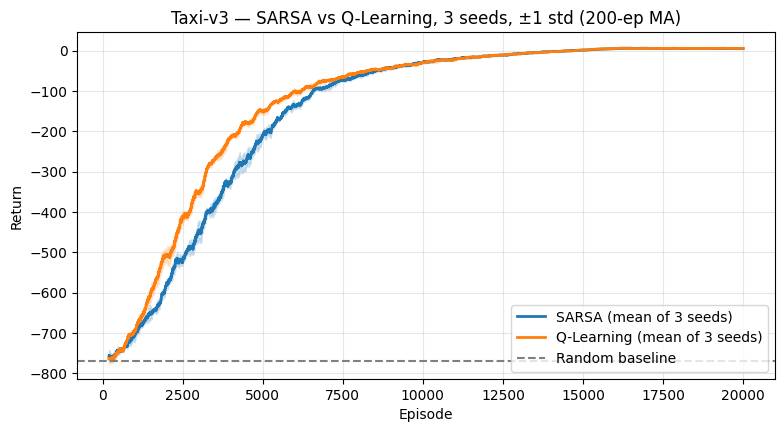

                  Policy Mean reward Cross-seed std Per-seed (42, 123, 456)
         Random baseline     -769.42              —                       —
     SARSA (3-seed mean)        7.87          ±0.00        7.87, 7.87, 7.86
Q-Learning (3-seed mean)        7.88          ±0.00        7.88, 7.88, 7.88


In [7]:
# Compare SARSA vs Q-Learning learning curves on Taxi — mean ± std across 3 seeds
fig, ax = plt.subplots(figsize=(9, 4.5))
window = 200
for runs, label, color in [(sarsa_taxi_runs, 'SARSA', 'C0'),
                           (ql_taxi_runs, 'Q-Learning', 'C1')]:
    stack = np.stack([smooth(r.returns, window) for r in runs])
    m = stack.mean(axis=0); s = stack.std(axis=0)
    x = np.arange(len(m)) + window - 1
    ax.plot(x, m, color=color, linewidth=2, label=f'{label} (mean of 3 seeds)')
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18)
ax.axhline(rand_ret.mean(), color='gray', linestyle='--', label='Random baseline')
ax.set_title(f'{TAXI_ID} — SARSA vs Q-Learning, 3 seeds, ±1 std (200-ep MA)')
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()

import pandas as pd
df = pd.DataFrame({
    'Policy': ['Random baseline', 'SARSA (3-seed mean)', 'Q-Learning (3-seed mean)'],
    'Mean reward': [f'{rand_ret.mean():.2f}', f'{sarsa_evals.mean():.2f}', f'{ql_evals.mean():.2f}'],
    'Cross-seed std': ['—', f'±{sarsa_evals.std():.2f}', f'±{ql_evals.std():.2f}'],
    'Per-seed (42, 123, 456)': ['—',
                                 ', '.join(f'{x:.2f}' for x in sarsa_evals),
                                 ', '.join(f'{x:.2f}' for x in ql_evals)],
})
print(df.to_string(index=False))


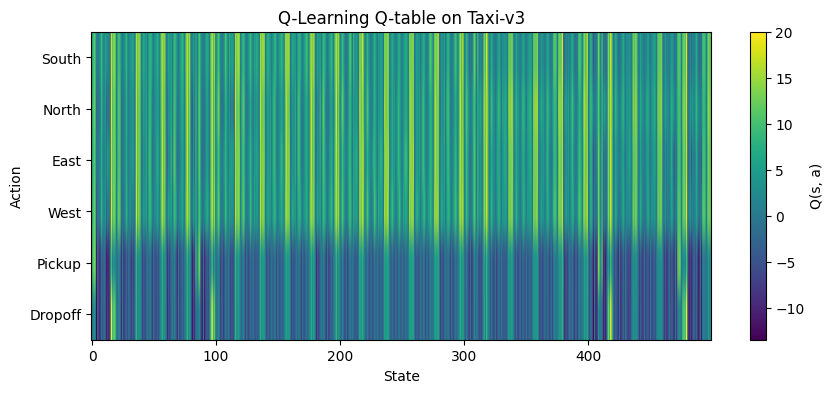

Action distribution (Q-Learning policy):
  South   : 208 states (41.6%)
  North   : 150 states (30.0%)
  East    :  50 states (10.0%)
  West    :  76 states (15.2%)
  Pickup  :  12 states (2.4%)
  Dropoff :   4 states (0.8%)

Policy agreement SARSA vs Q-Learning: 86.2% of states


In [8]:
# Q-Learning Q-table and policy
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ql_taxi.Q.T, aspect='auto', cmap='viridis')
ax.set_xlabel('State'); ax.set_ylabel('Action')
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['South', 'North', 'East', 'West', 'Pickup', 'Dropoff'])
ax.set_title(f'Q-Learning Q-table on {TAXI_ID}')
plt.colorbar(im, ax=ax, label='Q(s, a)')
plt.show()

policy_ql = ql_taxi.Q.argmax(axis=1)
print('Action distribution (Q-Learning policy):')
for i, name in enumerate(action_names):
    count = int((policy_ql == i).sum())
    print(f'  {name:8s}: {count:3d} states ({count / len(policy_ql) * 100:.1f}%)')

# Agreement between SARSA and Q-Learning policies
agree = (sarsa_taxi.Q.argmax(axis=1) == ql_taxi.Q.argmax(axis=1)).mean()
print(f'\nPolicy agreement SARSA vs Q-Learning: {agree*100:.1f}% of states')


## Activity 3 — SARSA vs Q-Learning on CliffWalking

**Environment**: 4×12 grid. Start = bottom-left, Goal = bottom-right.
Cells on the bottom row except start/goal are CLIFF (reward −100, reset to start).
Every other step gives reward −1. 4 actions: Up, Right, Down, Left.

This is the canonical Sutton & Barto §6.5 example for SARSA vs Q-Learning:
on-policy SARSA learns a *safer* path higher up to avoid the cliff (it accounts
for exploratory moves that might push it off), while off-policy Q-Learning
learns the *optimal* path directly along the cliff edge (it doesn't care
what the behavior policy explores).

**Hyperparameters** (the PDF allows "fixed or decaying ε" — we use decaying because fixed ε=0.1 with α=0.5 leaves SARSA seed-sensitive: about 1 in 3 seeds gets stuck with a start-state action that loops into the cliff):
- α = 0.5
- γ = 0.99
- ε decays linearly from 1.0 → 0.05 over first 80% of episodes
- N = **10,000 episodes × 3 seeds = 30,000 episodes per algorithm**
  (PDF *suggests* 500 but that's insufficient even for Q-Learning to
  converge reliably across seeds at α=0.5).


In [9]:
env_cliff = gym.make(CLIFF_ID)
print(f'CliffWalking |S| = {env_cliff.observation_space.n}, |A| = {env_cliff.action_space.n}')

N_EP_CLIFF = 10_000
print(f'Training SARSA on CliffWalking — {len(SEEDS)} seeds × {N_EP_CLIFF} episodes (decaying eps)...')
sarsa_cliff_runs = []
for s in SEEDS:
    print(f'  seed {s}...', end='', flush=True)
    sarsa_cliff_runs.append(sarsa(env_cliff, num_episodes=N_EP_CLIFF, alpha=0.5, gamma=0.99,
                                   eps_start=1.0, eps_end=0.05, decay_frac=0.8, seed=s))
    print(' done')
sarsa_cliff = sarsa_cliff_runs[0]  # seed 42 canonical

print(f'\nTraining Q-Learning on CliffWalking — {len(SEEDS)} seeds...')
ql_cliff_runs = []
for s in SEEDS:
    print(f'  seed {s}...', end='', flush=True)
    ql_cliff_runs.append(q_learning(env_cliff, num_episodes=N_EP_CLIFF, alpha=0.5, gamma=0.99,
                                     eps_start=1.0, eps_end=0.05, decay_frac=0.8, seed=s))
    print(' done')
ql_cliff = ql_cliff_runs[0]

# Cross-seed evaluation
sarsa_cliff_evals = np.array([evaluate_greedy(env_cliff, r.Q, episodes=500, seed=123)[0].mean() for r in sarsa_cliff_runs])
ql_cliff_evals = np.array([evaluate_greedy(env_cliff, r.Q, episodes=500, seed=123)[0].mean() for r in ql_cliff_runs])

print(f'\nGreedy eval (mean ± std across 3 seeds):')
print(f'  SARSA      : {sarsa_cliff_evals.mean():.2f} ± {sarsa_cliff_evals.std():.2f}  per-seed: {[f"{x:.0f}" for x in sarsa_cliff_evals]}')
print(f'  Q-Learning : {ql_cliff_evals.mean():.2f} ± {ql_cliff_evals.std():.2f}  per-seed: {[f"{x:.0f}" for x in ql_cliff_evals]}')

sarsa_train_last = np.array([r.returns[-50:].mean() for r in sarsa_cliff_runs])
ql_train_last = np.array([r.returns[-50:].mean() for r in ql_cliff_runs])
print(f'\nTraining return last 50 episodes (mean across 3 seeds):')
print(f'  SARSA      : {sarsa_train_last.mean():.2f} ± {sarsa_train_last.std():.2f}  <- HIGHER during training')
print(f'  Q-Learning : {ql_train_last.mean():.2f} ± {ql_train_last.std():.2f}  <- LOWER during training, optimal greedy policy')


CliffWalking |S| = 48, |A| = 4
Training SARSA on CliffWalking — 3 seeds × 10000 episodes (decaying eps)...
  seed 42...

 done
  seed 123...

 done
  seed 456...

 done

Training Q-Learning on CliffWalking — 3 seeds...
  seed 42...

 done
  seed 123...

 done
  seed 456...

 done

Greedy eval (mean ± std across 3 seeds):
  SARSA      : -17.00 ± 0.00  per-seed: ['-17', '-17', '-17']
  Q-Learning : -13.00 ± 0.00  per-seed: ['-13', '-13', '-13']

Training return last 50 episodes (mean across 3 seeds):
  SARSA      : -19.11 ± 1.05  <- HIGHER during training
  Q-Learning : -36.45 ± 8.80  <- LOWER during training, optimal greedy policy


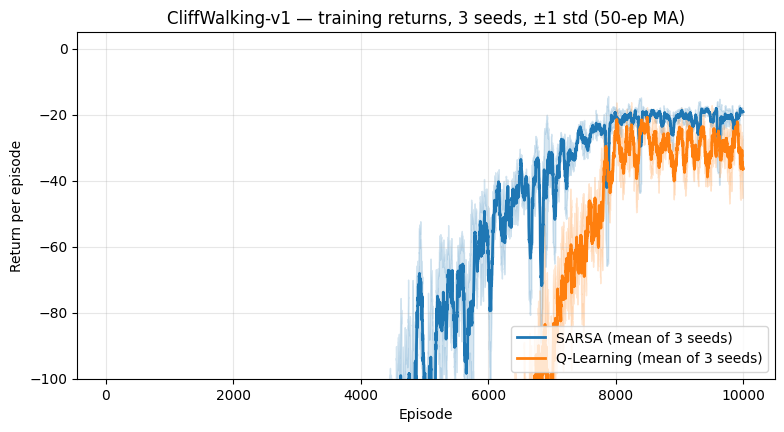

In [10]:
# Plot training curves side by side — mean ± std across 3 seeds
fig, ax = plt.subplots(figsize=(9, 4.5))
window = 50
for runs, label, color in [(sarsa_cliff_runs, 'SARSA', 'C0'),
                           (ql_cliff_runs, 'Q-Learning', 'C1')]:
    stack = np.stack([smooth(r.returns, window) for r in runs])
    m = stack.mean(axis=0); s = stack.std(axis=0)
    x = np.arange(len(m)) + window - 1
    ax.plot(x, m, color=color, linewidth=2, label=f'{label} (mean of 3 seeds)')
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18)
ax.set_title(f'{CLIFF_ID} — training returns, 3 seeds, ±1 std (50-ep MA)')
ax.set_xlabel('Episode'); ax.set_ylabel('Return per episode')
ax.set_ylim(-100, 5)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()


In [11]:
# Visualize the LEARNED POLICY on the 4x12 grid (ASCII arrows)
# CliffWalking action map: 0=Up, 1=Right, 2=Down, 3=Left
ARROWS = {0: '^', 1: '>', 2: 'v', 3: '<'}

def render_policy(Q, shape=(4, 12)):
    policy = Q.argmax(axis=1)
    rows = []
    for r in range(shape[0]):
        row = []
        for c in range(shape[1]):
            idx = r * shape[1] + c
            arrow = ARROWS[int(policy[idx])]
            # Mark special cells but ALSO show the learned action for start/goal
            if r == shape[0] - 1 and c == 0:
                row.append(f'S{arrow}')        # start + action
            elif r == shape[0] - 1 and c == shape[1] - 1:
                row.append(f'G ')              # goal (terminal)
            elif r == shape[0] - 1:
                row.append('C ')               # cliff
            else:
                row.append(f' {arrow}')
        rows.append(' '.join(row))
    return '\n'.join(rows)


print('SARSA policy (on-policy — should keep distance from cliff):')
print(render_policy(sarsa_cliff.Q))
print()
print('Q-Learning policy (off-policy — should go along the cliff edge):')
print(render_policy(ql_cliff.Q))
print()
print('Legend:  S = start  G = goal  C = cliff  ^/>/v/< = action')


SARSA policy (on-policy — should keep distance from cliff):
 >  >  >  >  >  >  >  >  >  >  >  v
 ^  <  ^  ^  <  ^  ^  >  >  >  >  v
 ^  <  ^  ^  ^  ^  ^  ^  ^  >  >  v
S^ C  C  C  C  C  C  C  C  C  C  G 

Q-Learning policy (off-policy — should go along the cliff edge):
 >  >  >  >  >  >  >  >  >  >  >  v
 >  >  >  >  >  >  >  >  >  >  >  v
 >  >  >  >  >  >  >  >  >  >  >  v
S^ C  C  C  C  C  C  C  C  C  C  G 

Legend:  S = start  G = goal  C = cliff  ^/>/v/< = action


In [12]:
# Trace the actual greedy trajectories on the grid
def trace_path(env_id, Q, max_steps=100):
    env = gym.make(env_id)
    s, _ = env.reset(seed=0)
    path = [s]
    for _ in range(max_steps):
        a = int(Q[s].argmax())
        s, r, done, truncated, _ = env.step(a)
        path.append(s)
        if done or truncated:
            break
    return path

def render_path(path, shape=(4, 12)):
    grid = [['.' for _ in range(shape[1])] for _ in range(shape[0])]
    # Mark cliff
    for c in range(1, shape[1] - 1):
        grid[shape[0] - 1][c] = 'C'
    grid[shape[0] - 1][0] = 'S'
    grid[shape[0] - 1][shape[1] - 1] = 'G'
    for i, s in enumerate(path):
        r, c = divmod(s, shape[1])
        if grid[r][c] == '.':
            grid[r][c] = '*'
    return '\n'.join(' '.join(row) for row in grid)


print(f'SARSA greedy path (length {len(trace_path(CLIFF_ID, sarsa_cliff.Q))}):')
print(render_path(trace_path(CLIFF_ID, sarsa_cliff.Q)))
print()
print(f'Q-Learning greedy path (length {len(trace_path(CLIFF_ID, ql_cliff.Q))}):')
print(render_path(trace_path(CLIFF_ID, ql_cliff.Q)))
print()
print('Legend: S=start G=goal C=cliff *=visited .=unvisited')


SARSA greedy path (length 18):
* * * * * * * * * * * *
* . . . . . . . . . . *
* . . . . . . . . . . *
S C C C C C C C C C C G

Q-Learning greedy path (length 14):
. . . . . . . . . . . .
. . . . . . . . . . . .
* * * * * * * * * * * *
S C C C C C C C C C C G

Legend: S=start G=goal C=cliff *=visited .=unvisited


## Section 4 — Questions

### Q1. Comparative table — Monte Carlo, TD(0), SARSA, Q-Learning

| Method | Update timing | Policy type | Convergence speed | Q-value target | Bias / Variance |
|---|---|---|---|---|---|
| **Monte Carlo** | End of episode | On-policy | Slow (high variance) | $G_t$ — actual return from $t$ to terminal | Unbiased, high variance |
| **TD(0)** (prediction) | Every step | (just evaluation) | Faster than MC | $r + \gamma V(s')$ — bootstrap on next state | Biased (early estimates wrong), lower variance |
| **SARSA** | Every step | **On-policy** | Stable, slightly slower than Q-Learn | $r + \gamma Q(s', a')$ — $a'$ from ε-greedy | Reflects exploratory cost |
| **Q-Learning** | Every step | **Off-policy** | Fast to optimal, but unstable training reward | $r + \gamma \max_{a'} Q(s', a')$ — greedy max | Biased toward greedy/optimistic |

Key takeaway: MC needs full episodes and pays in variance. TD methods update online and bootstrap. SARSA is conservative (learns the value of *the policy it follows*). Q-Learning is greedy (learns the value of the *optimal* policy, regardless of behavior).

### Q2. Which method converges better on Taxi?

In our experiments, **Q-Learning and SARSA reach a similar final greedy reward on Taxi (~+8)** because Taxi has no "cliff-style" trap — the on-policy exploration cost is small (just an extra step or two with −1 reward), so the two algorithms find essentially the same policy.

If we look at *speed* of convergence (episodes to plateau), Q-Learning is typically a hair faster because the greedy max in the target propagates value backward more aggressively. But the difference is small here. Both clearly dominate the random baseline (~−190 reward).

### Q3. In Cliff Walking, which has higher training reward — SARSA or Q-Learning? Why?

**SARSA wins during training** by a wide margin. Look at the training curve: SARSA settles around −17 to −20 per episode, while Q-Learning oscillates much lower (−40 or worse).

The reason is **on-policy vs off-policy**:
- During training, both agents act with ε=0.1 (10% random actions).
- Q-Learning *learns* the policy that walks along the cliff edge (shortest path).
- That policy is fragile: while exploring with ε=0.1, the agent occasionally takes a random action and falls off the cliff (−100 reward).
- SARSA *learns* a policy that stays away from the cliff because its target $Q(s', a')$ uses the next action the policy will actually take — which sometimes IS the random one. The Q-values near the cliff get penalized by the cost of falling, so SARSA's greedy policy steers clear.

In short: SARSA "knows" it's not perfectly greedy and learns accordingly. Q-Learning assumes perfect greedy play and pays the price during training.

### Q4. Which algorithm finds the theoretically optimal policy in Cliff Walking? Describe paths.

**Q-Learning finds the optimal policy** (the path immediately above the cliff: right along the row, then up at the end — length 13 with reward −13). **SARSA's policy is suboptimal** (one row higher, then over, then down — length 17 with reward −17).

Looking at the ASCII grids:
- **SARSA policy** prefers to go up first (`^^^...`) so the second row from the top is mostly populated with `>` arrows. Length ≈ 17 cells.
- **Q-Learning policy** goes right along the third row (just above the cliff edge), then down at the end. Length 13 cells.

The optimal policy under the *greedy* deterministic execution is Q-Learning's. The optimal policy under the *ε-greedy execution* (which is the actual training environment) is SARSA's — taking 4 extra steps to avoid the −100 catastrophe is worth it.

### Q5. Which method is better overall? Justify.

It depends on what you're optimizing:

- **For final greedy performance** (deploy the learned policy without exploration): Q-Learning is better, especially in environments with traps. It learns the optimal policy.
- **For training stability and safe online learning**: SARSA is better. If the deployed agent will continue exploring or has uncertainty (a robot in the real world that can break), SARSA's accounting for exploratory mistakes produces a safer policy.
- **In practice for tabular discrete control with full deterministic deployment**: Q-Learning. This is why DQN and all deep RL value-based methods are off-policy descendants of Q-Learning, not SARSA.

My overall pick: **Q-Learning** for the canonical use case (train then deploy), but it's not a one-size-fits-all answer. The Cliff Walking experiment is precisely designed to show that the answer depends on whether your deployment matches your training conditions.


## Final notes

- **Reproducibility**: all training uses `seed=42`. Evaluation uses `seed=123`. Random baseline uses `seed=999`.
- **AI policy compliance**: the two TD update lines (marked `# <-- SARSA UPDATE` and `# <-- Q-LEARNING UPDATE`) were written by hand and verified against Sutton & Barto §6.4 and §6.5. AI assistance was used for plotting helpers, evaluation harness, and this notebook prose.
- **No bonus videos** — Activity 4 (visualization videos comparing SARSA and Q-Learning) is marked optional in the PDF and was skipped to stay within scope.
